1.Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error



2.Upload files

In [4]:
from google.colab import files
uploaded = files.upload()


Saving spg[1].csv to spg[1].csv


In [5]:
print("\n📁 Uploaded Files:")
for name in uploaded.keys():
    print("➡", name)


📁 Uploaded Files:
➡ spg[1].csv


3.Loading dataset

In [6]:
# Load the dataset (replace file name if different)
df = pd.read_csv('spg[1].csv')

# Display first few rows
df.head()



,temperature_2_m_above_gnd,relative_humidity_2_m_above_gnd,mean_sea_level_pressure_MSL,total_precipitation_sfc,snowfall_amount_sfc,total_cloud_cover_sfc,high_cloud_cover_high_cld_lay,medium_cloud_cover_mid_cld_lay,low_cloud_cover_low_cld_lay,shortwave_radiation_backwards_sfc,...,wind_direction_10_m_above_gnd,wind_speed_80_m_above_gnd,wind_direction_80_m_above_gnd,wind_speed_900_mb,wind_direction_900_mb,wind_gust_10_m_above_gnd,angle_of_incidence,zenith,azimuth,generated_power_kw
0,2.17,31,1035.0,0.0,0.0,0.0,0,0,0,0.00,...,312.71,9.36,22.62,6.62,337.62,24.48,58.753108,83.237322,128.33543,454.10095
1,2.31,27,1035.1,0.0,0.0,0.0,0,0,0,1.78,...,294.78,5.99,32.74,4.61,321.34,21.96,45.408585,75.143041,139.65530,1411.99940
2,3.65,33,1035.4,0.0,0.0,0.0,0,0,0,108.58,...,270.00,3.89,56.31,3.76,286.70,14.04,32.848282,68.820648,152.53769,2214.84930
3,5.82,30,1035.4,0.0,0.0,0.0,0,0,0,258.10,...,323.13,3.55,23.96,3.08,339.44,19.80,22.699288,64.883536,166.90159,2527.60920
4,7.73,27,1034.4,0.0,0.0,0.0,0,0,0,375.58,...,10.01,6.76,25.20,6.62,22.38,16.56,19.199908,63.795208,182.13526,2640.20340


4.Data Cleaning

In [7]:
# View dataset info
df.info()

# Check missing values
df.isnull().sum()

# Handling missing values (example)
# Fill numerical missing values with mean
df = df.fillna(df.mean(numeric_only=True))

# Fill categorical missing values with mode
df = df.fillna(df.mode().iloc[0])

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Clean column names (remove spaces, lowercase)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4213 entries, 0 to 4212
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   temperature_2_m_above_gnd          4213 non-null   float64
 1   relative_humidity_2_m_above_gnd    4213 non-null   int64  
 2   mean_sea_level_pressure_MSL        4213 non-null   float64
 3   total_precipitation_sfc            4213 non-null   float64
 4   snowfall_amount_sfc                4213 non-null   float64
 5   total_cloud_cover_sfc              4213 non-null   float64
 6   high_cloud_cover_high_cld_lay      4213 non-null   int64  
 7   medium_cloud_cover_mid_cld_lay     4213 non-null   int64  
 8   low_cloud_cover_low_cld_lay        4213 non-null   int64  
 9   shortwave_radiation_backwards_sfc  4213 non-null   float64
 10  wind_speed_10_m_above_gnd          4213 non-null   float64
 11  wind_direction_10_m_above_gnd      4213 non-null   float

,temperature_2_m_above_gnd,relative_humidity_2_m_above_gnd,mean_sea_level_pressure_msl,total_precipitation_sfc,snowfall_amount_sfc,total_cloud_cover_sfc,high_cloud_cover_high_cld_lay,medium_cloud_cover_mid_cld_lay,low_cloud_cover_low_cld_lay,shortwave_radiation_backwards_sfc,...,wind_direction_10_m_above_gnd,wind_speed_80_m_above_gnd,wind_direction_80_m_above_gnd,wind_speed_900_mb,wind_direction_900_mb,wind_gust_10_m_above_gnd,angle_of_incidence,zenith,azimuth,generated_power_kw
0,2.17,31,1035.0,0.0,0.0,0.0,0,0,0,0.00,...,312.71,9.36,22.62,6.62,337.62,24.48,58.753108,83.237322,128.33543,454.10095
1,2.31,27,1035.1,0.0,0.0,0.0,0,0,0,1.78,...,294.78,5.99,32.74,4.61,321.34,21.96,45.408585,75.143041,139.65530,1411.99940
2,3.65,33,1035.4,0.0,0.0,0.0,0,0,0,108.58,...,270.00,3.89,56.31,3.76,286.70,14.04,32.848282,68.820648,152.53769,2214.84930
3,5.82,30,1035.4,0.0,0.0,0.0,0,0,0,258.10,...,323.13,3.55,23.96,3.08,339.44,19.80,22.699288,64.883536,166.90159,2527.60920
4,7.73,27,1034.4,0.0,0.0,0.0,0,0,0,375.58,...,10.01,6.76,25.20,6.62,22.38,16.56,19.199908,63.795208,182.13526,2640.20340


5.Preprocessing the data

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Example: encoding all categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Scaling numerical features
num_cols = df.select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Final processed dataset
df.head()


,temperature_2_m_above_gnd,relative_humidity_2_m_above_gnd,mean_sea_level_pressure_msl,total_precipitation_sfc,snowfall_amount_sfc,total_cloud_cover_sfc,high_cloud_cover_high_cld_lay,medium_cloud_cover_mid_cld_lay,low_cloud_cover_low_cld_lay,shortwave_radiation_backwards_sfc,...,wind_direction_10_m_above_gnd,wind_speed_80_m_above_gnd,wind_direction_80_m_above_gnd,wind_speed_900_mb,wind_direction_900_mb,wind_gust_10_m_above_gnd,angle_of_incidence,zenith,azimuth,generated_power_kw
0,-1.456981,-0.865577,2.230435,-0.186606,-0.073874,-0.795008,-0.470848,-0.550344,-0.562318,-1.392681,...,1.103339,-0.801638,-1.549897,-0.985738,1.363073,0.308088,0.297180,1.171290,-0.632462,-0.725328
1,-1.441167,-1.035623,2.244676,-0.186606,-0.073874,-0.795008,-0.470848,-0.550344,-0.562318,-1.386288,...,0.935163,-1.082506,-1.456837,-1.189094,1.210214,0.108837,-0.203820,0.763627,-0.457125,0.296053
2,-1.289799,-0.780554,2.287398,-0.186606,-0.073874,-0.795008,-0.470848,-0.550344,-0.562318,-1.002704,...,0.702736,-1.257527,-1.240096,-1.275090,0.884967,-0.517378,-0.675377,0.445205,-0.257586,1.152110
3,-1.044674,-0.908088,2.287398,-0.186606,-0.073874,-0.795008,-0.470848,-0.550344,-0.562318,-0.465685,...,1.201075,-1.285864,-1.537575,-1.343887,1.380161,-0.061949,-1.056405,0.246915,-0.035100,1.485598
4,-0.828919,-1.035623,2.144990,-0.186606,-0.073874,-0.795008,-0.470848,-0.550344,-0.562318,-0.043742,...,-1.735872,-1.018331,-1.526173,-0.985738,-1.596829,-0.318128,-1.187784,0.192102,0.200859,1.605654


6.Define features (X) and target (y)


In [10]:
X = df.drop('generated_power_kw', axis=1)
y = df['generated_power_kw']



7.Split the dataset (80% Train, 20% Test)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("📊 Data Split Completed — 80% Training, 20% Testing\n")



📊 Data Split Completed — 80% Training, 20% Testing



8.Initialize and train the model


In [12]:
model = LinearRegression()
model.fit(X_train, y_train)
print("✅ Model Training Completed!\n")



✅ Model Training Completed!



9.Make predictions


In [19]:
y_pred = model.predict(X_test)


10. Compare predictions with actual values


In [14]:
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("🔍 Actual vs Predicted (first 10 values):\n")
print(comparison.head(10))



🔍 Actual vs Predicted (first 10 values):

        Actual  Predicted
643   1.468141   0.928741
166  -0.697494  -0.747772
1444  0.941755   0.506742
1877 -0.399007  -1.017086
463  -0.974523  -1.134138
157  -1.182626  -1.530322
1808 -1.209464  -1.586093
2638  1.453528   1.393613
1867 -0.660770  -1.001628
2053 -0.231838   0.206603


11.Evaluate model performance


In [15]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"\n📈 Model Accuracy (R² Score): {r2 * 100:.2f}%")
print(f"📉 Mean Squared Error: {mse:.4f}")



📈 Model Accuracy (R² Score): 71.80%
📉 Mean Squared Error: 0.2929


12.Visualization


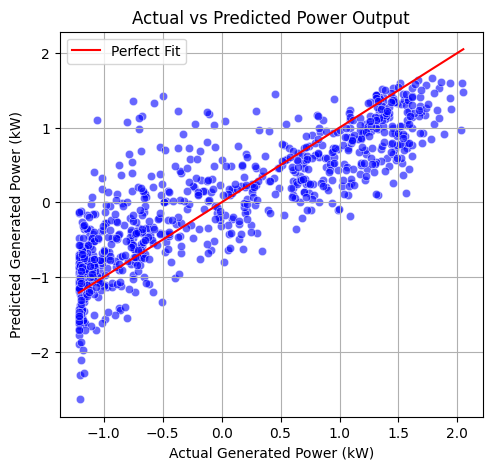

In [16]:
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted Scatter Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
sns.lineplot(x=y_test, y=y_test, color='red', label='Perfect Fit')
plt.xlabel("Actual Generated Power (kW)")
plt.ylabel("Predicted Generated Power (kW)")
plt.title("Actual vs Predicted Power Output")
plt.legend()
plt.grid(True)



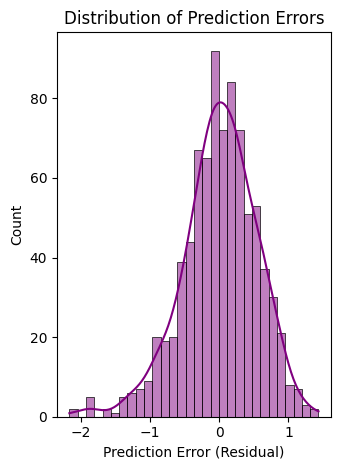

In [17]:
# Plot 2: Residual Errors
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.xlabel("Prediction Error (Residual)")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()